<a href="https://colab.research.google.com/github/Matheusbcy/-Data-Science-IA-/blob/main/Previs%C3%A3o_doen%C3%A7as_respiratorias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Departamento médico

## Importação das bibliotecas e base de dados

In [1]:
import os
import cv2
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers, optimizers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Input, Dense, AveragePooling2D, Dropout, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
xray_directory = "/content/drive/MyDrive/Dataset"

In [4]:
os.listdir(xray_directory)

['.DS_Store', '0', '1', '2', '3']

In [5]:
image_generator = ImageDataGenerator(rescale= 1./255)

In [6]:
train_generator = image_generator.flow_from_directory(batch_size = 40, directory = xray_directory, shuffle = True, target_size = (256, 256), class_mode = "categorical", subset = "training")

Found 532 images belonging to 4 classes.


In [7]:
train_images, train_labels = next(train_generator)

In [8]:
train_images.shape

(40, 256, 256, 3)

In [9]:
labels_names = {0: "Covid-19", 1: "Normal", 2: "Pneumonia viral", 3: "Pneumonia bacterial"}

## Visualizalção dos dados

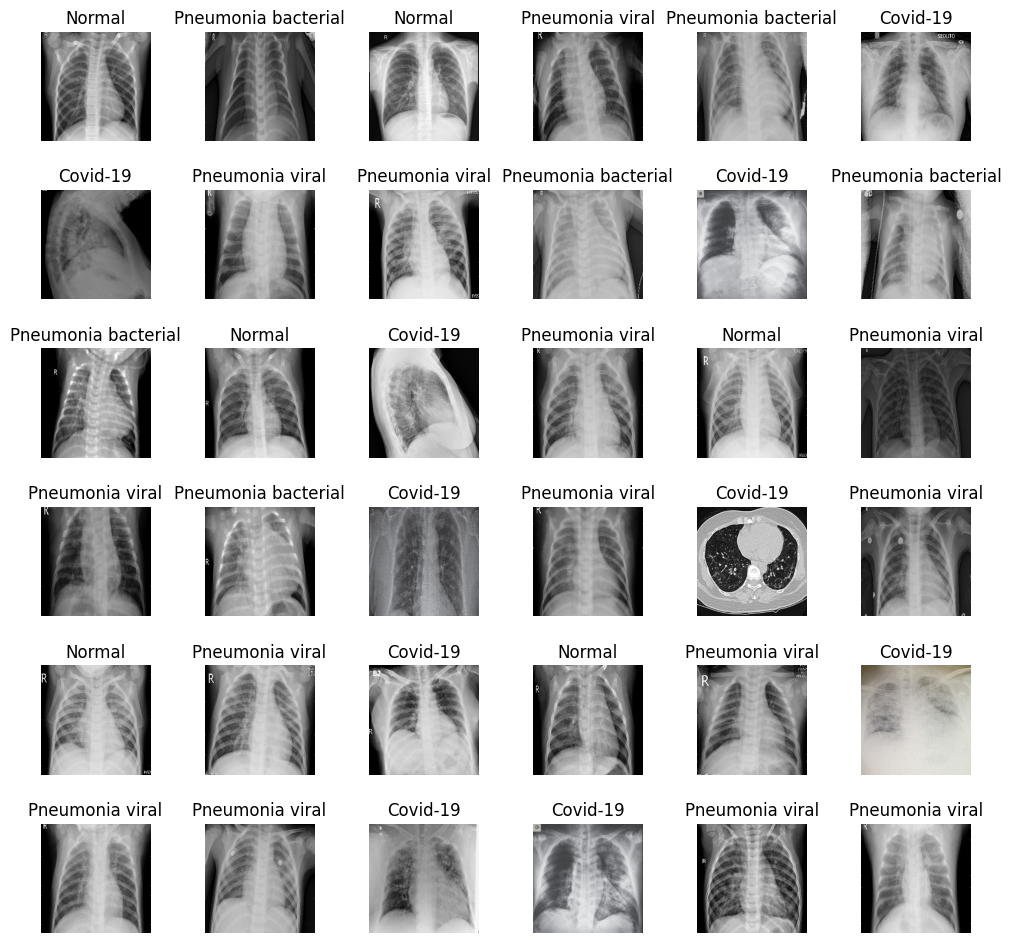

In [10]:
fig, axes = plt.subplots(nrows = 6, ncols = 6, figsize = (12, 12))
axes = axes.ravel()
for i in np.arange(0, 36):
  axes[i].imshow(train_images[i])
  axes[i].set_title(labels_names[np.argmax(train_labels[i])])
  axes[i].axis("off")
plt.subplots_adjust(wspace = 0.5)

## Carregamento da rede neural com pesos pré-treinados

In [11]:
base_model = ResNet50(weights="imagenet", include_top = False, input_tensor= Input(shape = (256, 256, 3)))

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [12]:
base_model.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 262, 262,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 64, 64,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 64, 64,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 64, 64,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 64, 64,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 64, 64,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [13]:
len(base_model.layers)

175

In [15]:
for layer in base_model.layers[:-10]:
  layer.trainable = False

## Construção e treinamento do modelo de deep learning

In [44]:
head_model = base_model.output
head_model = AveragePooling2D(pool_size=(2, 2))(head_model)
head_model = Flatten()(head_model)
head_model = Dense(256, activation = "relu")(head_model)
head_model = Dropout(0.2)(head_model)
head_model = Dense(256, activation = "relu")(head_model)
head_model = Dropout(0.2)(head_model)
head_model = Dense(4, activation= "softmax")(head_model)

In [45]:
model = Model(inputs = base_model.input, outputs = head_model)

In [46]:
model.compile(loss = "categorical_crossentropy", optimizer= optimizers.RMSprop(learning_rate = 1e-4),
              metrics = ["accuracy"])

In [47]:
checkpointer = ModelCheckpoint(filepath="weights.keras")

In [48]:
train_generator = image_generator.flow_from_directory(batch_size = 4, directory = xray_directory,
                                                      shuffle = True, target_size = (256, 256),
                                                      class_mode = "categorical", subset = "training")

Found 532 images belonging to 4 classes.


In [49]:
history = model.fit(train_generator, epochs = 25, callbacks = [checkpointer])

Epoch 1/25
133/133 ━━━━━━━━━━━━━━━━━━━━ 207s 1s/step - accuracy: 0.6496 - loss: 0.9013
Epoch 2/25
133/133 ━━━━━━━━━━━━━━━━━━━━ 194s 1s/step - accuracy: 0.8627 - loss: 0.4105
Epoch 3/25
133/133 ━━━━━━━━━━━━━━━━━━━━ 193s 1s/step - accuracy: 0.8705 - loss: 0.3849
Epoch 4/25
133/133 ━━━━━━━━━━━━━━━━━━━━ 209s 2s/step - accuracy: 0.8407 - loss: 0.3787
Epoch 5/25
133/133 ━━━━━━━━━━━━━━━━━━━━ 192s 1s/step - accuracy: 0.9136 - loss: 0.2876
Epoch 6/25
133/133 ━━━━━━━━━━━━━━━━━━━━ 190s 1s/step - accuracy: 0.8628 - loss: 0.4312
Epoch 7/25
133/133 ━━━━━━━━━━━━━━━━━━━━ 205s 1s/step - accuracy: 0.8806 - loss: 0.3802
Epoch 8/25
133/133 ━━━━━━━━━━━━━━━━━━━━ 193s 1s/step - accuracy: 0.8752 - loss: 0.3998
Epoch 9/25
133/133 ━━━━━━━━━━━━━━━━━━━━ 192s 1s/step - accuracy: 0.8612 - loss: 0.4025
Epoch 10/25
133/133 ━━━━━━━━━━━━━━━━━━━━ 190s 1s/step - accuracy: 0.9225 - loss: 0.2644
Epoch 11/25
133/133 ━━━━━━━━━━━━━━━━━━━━ 191s 1s/step - accuracy: 0.9151 - loss: 0.2936
Epoch 12/25
133/133 ━━━━━━━━━━━━━━━━━━━━ 

## Avaliação da rede neural

In [50]:
history.history.keys()

dict_keys(['accuracy', 'loss'])

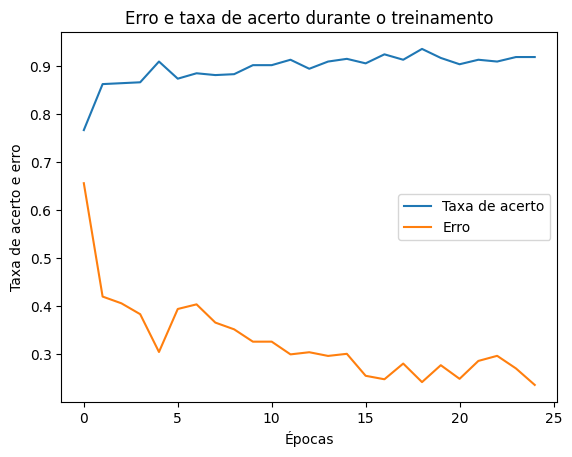

In [51]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["loss"])
plt.title("Erro e taxa de acerto durante o treinamento")
plt.xlabel("Épocas")
plt.ylabel("Taxa de acerto e erro")
plt.legend(["Taxa de acerto", "Erro"])

In [52]:
test_directory = "/content/drive/MyDrive/Test"

In [54]:
test_gen = ImageDataGenerator(rescale = 1./255)
test_generator = test_gen.flow_from_directory(batch_size = 40, directory = test_directory,
                                              shuffle = True, target_size = (256, 256),
                                              class_mode = "categorical")

Found 40 images belonging to 4 classes.


In [57]:
evaluate = model.evaluate(test_generator)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1/1 ━━━━━━━━━━━━━━━━━━━━ 17s 17s/step - accuracy: 0.5000 - loss: 4.9989


In [58]:
evaluate

[4.998870849609375, 0.5]

In [62]:
prediction = []
original = []
image = []
for i in range(len(os.listdir(test_directory))):
  for item in os.listdir(os.path.join(test_directory, str(i))):
    img = cv2.imread(os.path.join(test_directory, str(i), item))
    img = cv2.resize(img, (256, 256))
    image.append(img)
    img = img / 255
    img = img.reshape(-1, 256, 256, 3)
    predict = model.predict(img)
    predict = np.argmax(predict)
    prediction.append(predict)
    original.append(i)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 

In [65]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [66]:
accuracy_score(original, prediction)

0.525

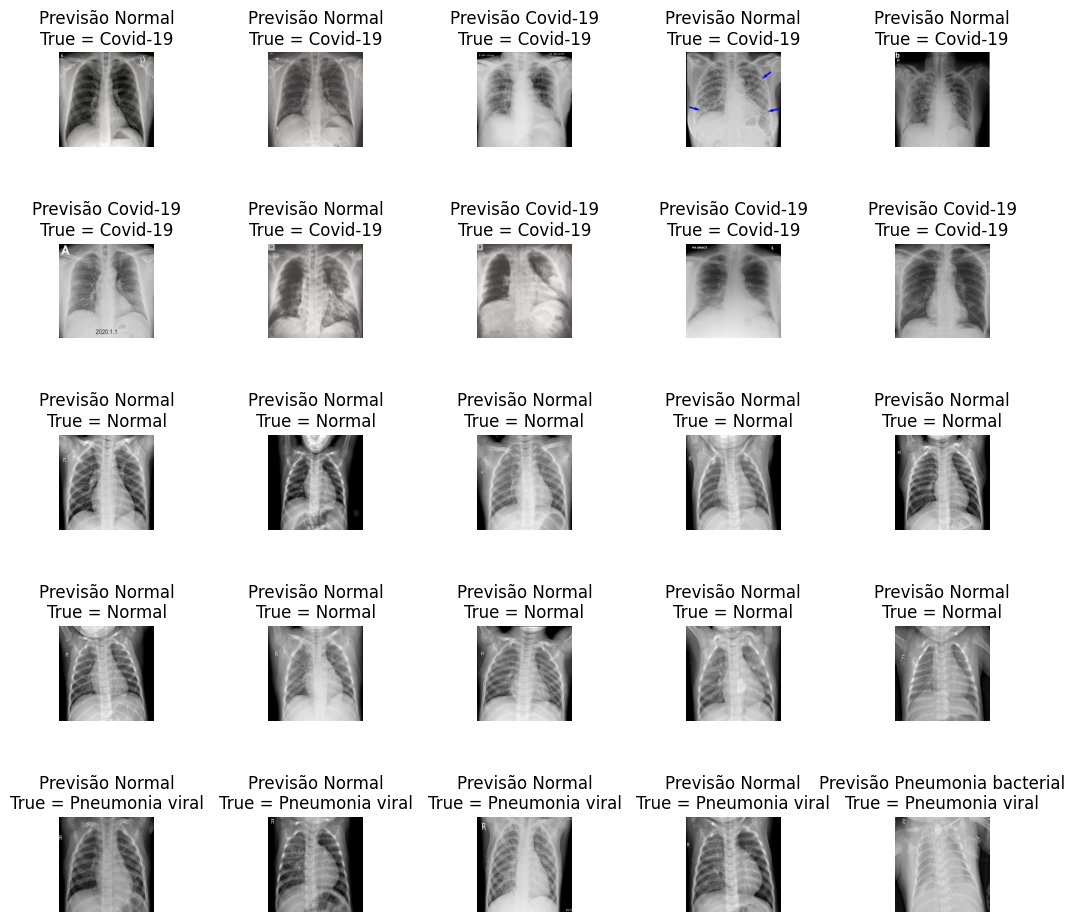

In [67]:
fig, axes = plt.subplots(5, 5, figsize = (12, 12))
axes = axes.ravel()
for i in np.arange(0, 25):
  axes[i].imshow(image[i])
  axes[i].set_title("Previsão {}\nTrue = {}".format(str(labels_names[prediction[i]]), str(labels_names[original[i]])))
  axes[i].axis("off")
plt.subplots_adjust(wspace = 1.2)

<Axes: >

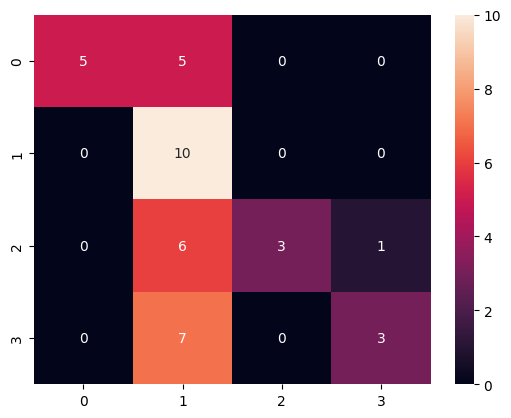

In [70]:
cm = confusion_matrix(original, prediction)
sns.heatmap(cm, annot = True)

In [71]:
print(classification_report(original, prediction))

              precision    recall  f1-score   support

           0       1.00      0.50      0.67        10
           1       0.36      1.00      0.53        10
           2       1.00      0.30      0.46        10
           3       0.75      0.30      0.43        10

    accuracy                           0.53        40
   macro avg       0.78      0.53      0.52        40
weighted avg       0.78      0.53      0.52        40



## Classificação de somente uma imagem

In [72]:
from keras.models import load_model
model_loaded = load_model("/content/weights.keras")

In [74]:
img = cv2.imread("/content/imagem_chamada_rx_torax_covid.jpg")

array([[[  3,   3,   3],
        [  4,   4,   4],
        [  4,   4,   4],
        ...,
        [  8,   8,   8],
        [ 10,  10,  10],
        [ 12,  12,  12]],

       [[  4,   4,   4],
        [  5,   5,   5],
        [  5,   5,   5],
        ...,
        [  9,   9,   9],
        [ 12,  12,  12],
        [ 14,  14,  14]],

       [[  4,   4,   4],
        [  5,   5,   5],
        [  5,   5,   5],
        ...,
        [  9,   9,   9],
        [ 12,  12,  12],
        [ 14,  14,  14]],

       ...,

       [[ 98,  98,  98],
        [118, 118, 118],
        [125, 125, 125],
        ...,
        [ 93,  93,  93],
        [107, 107, 107],
        [104, 104, 104]],

       [[104, 104, 104],
        [127, 127, 127],
        [134, 134, 134],
        ...,
        [ 99,  99,  99],
        [111, 111, 111],
        [110, 110, 110]],

       [[ 93,  93,  93],
        [114, 114, 114],
        [118, 118, 118],
        ...,
        [ 88,  88,  88],
        [ 97,  97,  97],
        [ 98,  98,  98]]], dtype=uint8)
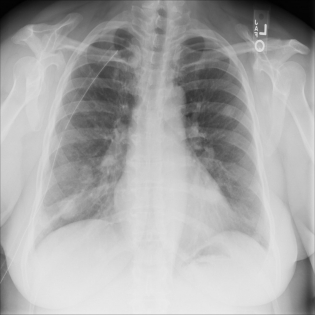

In [76]:
img

array([[[  3,   3,   3],
        [  4,   4,   4],
        [  4,   4,   4],
        ...,
        [  7,   7,   7],
        [  9,   9,   9],
        [ 12,  12,  12]],

       [[  4,   4,   4],
        [  5,   5,   5],
        [  5,   5,   5],
        ...,
        [  8,   8,   8],
        [ 11,  11,  11],
        [ 14,  14,  14]],

       [[  4,   4,   4],
        [  4,   4,   4],
        [  4,   4,   4],
        ...,
        [  8,   8,   8],
        [ 11,  11,  11],
        [ 14,  14,  14]],

       ...,

       [[ 97,  97,  97],
        [117, 117, 117],
        [126, 126, 126],
        ...,
        [ 88,  88,  88],
        [100, 100, 100],
        [102, 102, 102]],

       [[104, 104, 104],
        [126, 126, 126],
        [135, 135, 135],
        ...,
        [ 93,  93,  93],
        [105, 105, 105],
        [108, 108, 108]],

       [[ 97,  97,  97],
        [117, 117, 117],
        [123, 123, 123],
        ...,
        [ 86,  86,  86],
        [ 95,  95,  95],
        [ 99,  99,  99]]], dtype=uint8)
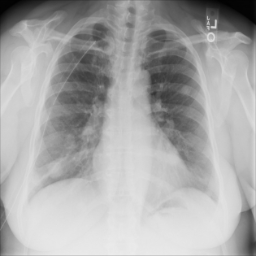

In [77]:
img = cv2.resize(img, (256, 256))
img

In [78]:
img = img / 255
img

array([[[0.01176471, 0.01176471, 0.01176471],
        [0.01568627, 0.01568627, 0.01568627],
        [0.01568627, 0.01568627, 0.01568627],
        ...,
        [0.02745098, 0.02745098, 0.02745098],
        [0.03529412, 0.03529412, 0.03529412],
        [0.04705882, 0.04705882, 0.04705882]],

       [[0.01568627, 0.01568627, 0.01568627],
        [0.01960784, 0.01960784, 0.01960784],
        [0.01960784, 0.01960784, 0.01960784],
        ...,
        [0.03137255, 0.03137255, 0.03137255],
        [0.04313725, 0.04313725, 0.04313725],
        [0.05490196, 0.05490196, 0.05490196]],

       [[0.01568627, 0.01568627, 0.01568627],
        [0.01568627, 0.01568627, 0.01568627],
        [0.01568627, 0.01568627, 0.01568627],
        ...,
        [0.03137255, 0.03137255, 0.03137255],
        [0.04313725, 0.04313725, 0.04313725],
        [0.05490196, 0.05490196, 0.05490196]],

       ...,

       [[0.38039216, 0.38039216, 0.38039216],
        [0.45882353, 0.45882353, 0.45882353],
        [0.49411765, 0

In [80]:
img = img.reshape(-1, 256, 256, 3)
img.shape

(1, 256, 256, 3)

In [83]:
predict = model_loaded(img)
predict

<tf.Tensor: shape=(1, 4), dtype=float32, numpy=
array([[9.5426470e-01, 4.2778250e-02, 2.7893099e-03, 1.6763764e-04]],
      dtype=float32)>

In [84]:
predict = np.argmax(predict)
predict

np.int64(0)

In [85]:
labels_names[predict]

'Covid-19'

Proximo passos é melhorar o accuracy modificando os paramêtros para treinamento